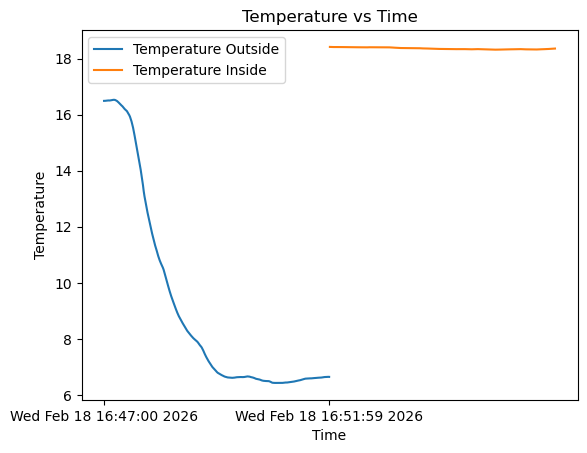

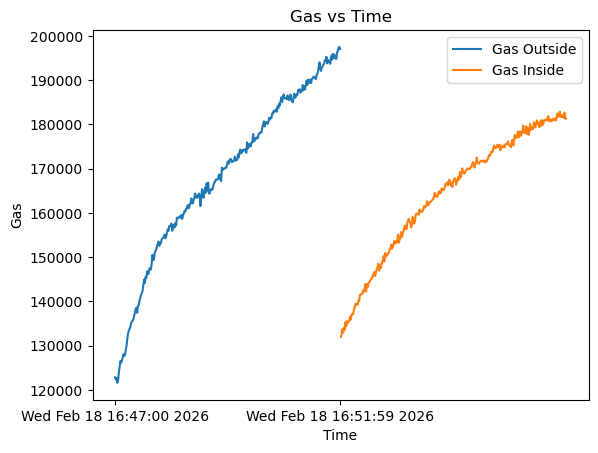

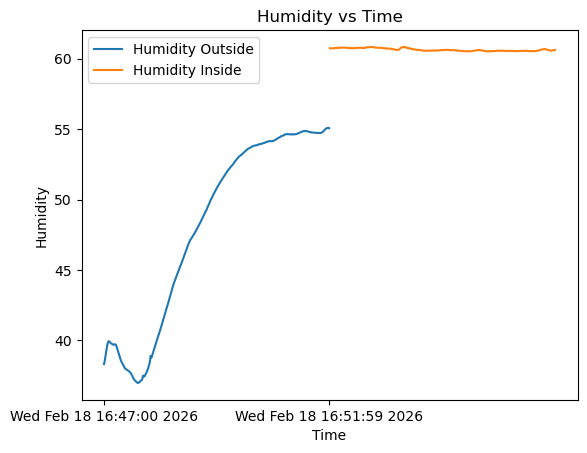

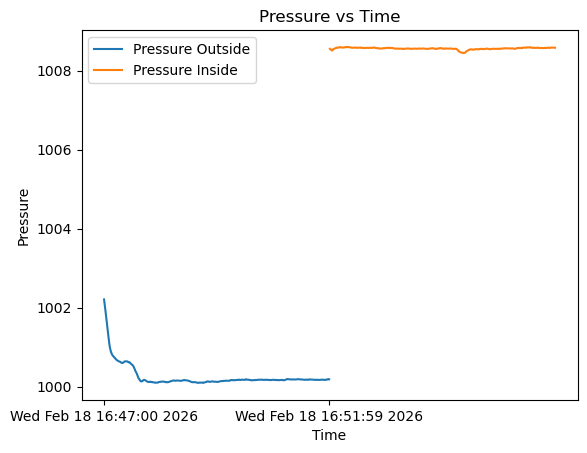

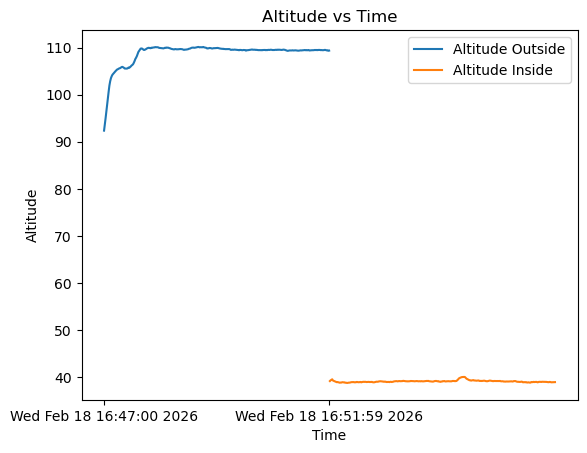

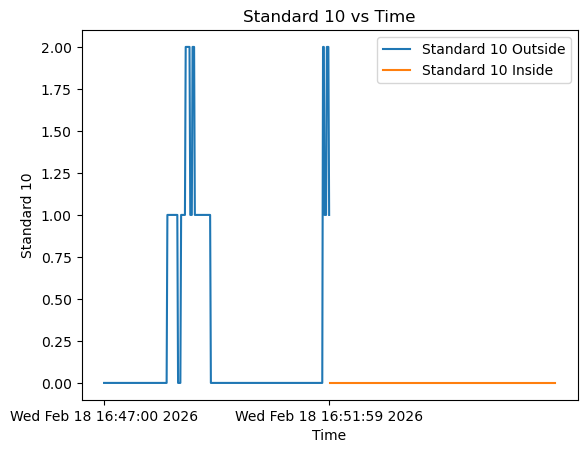

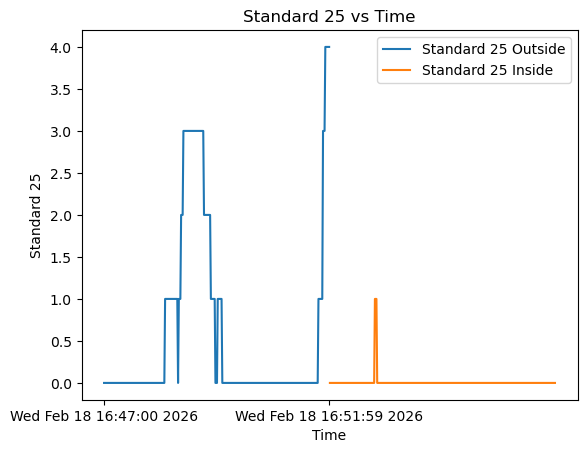

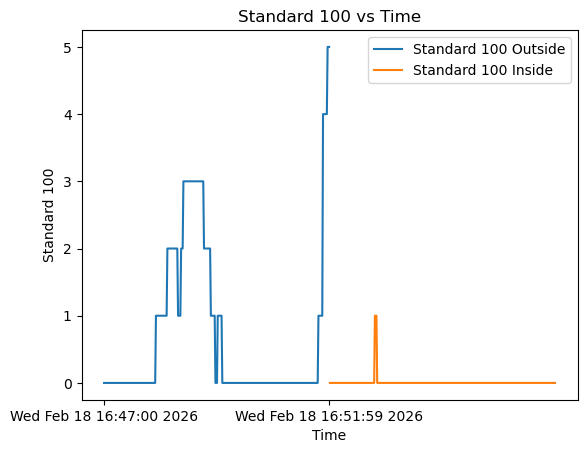

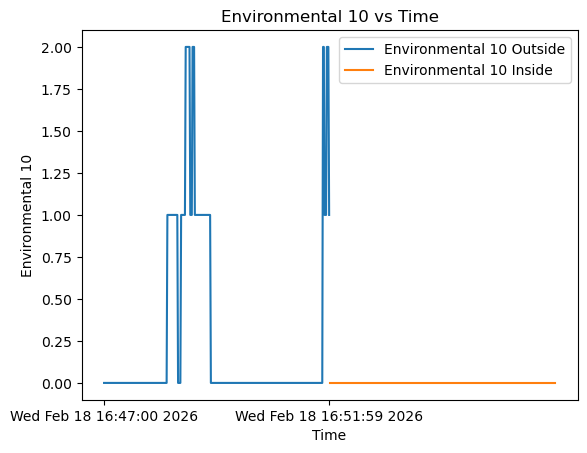

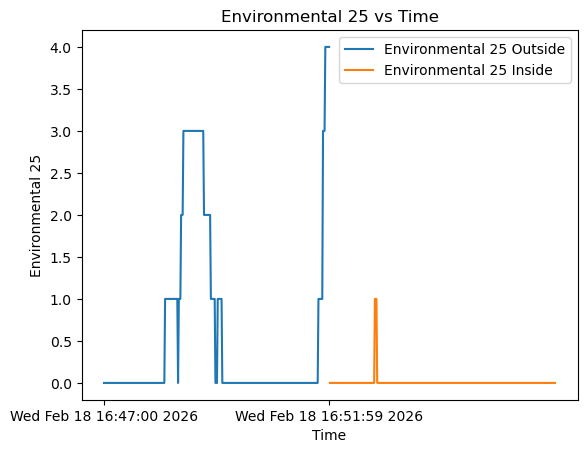

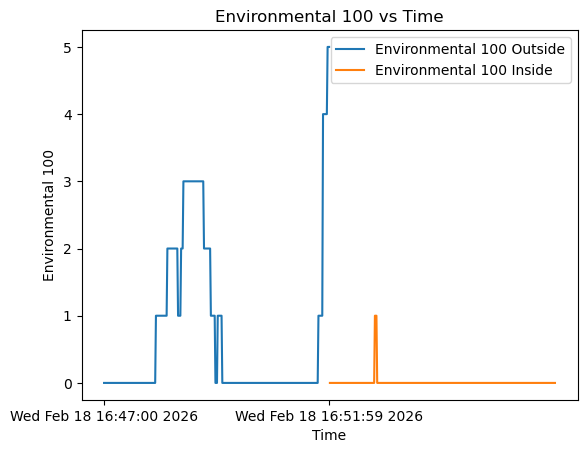

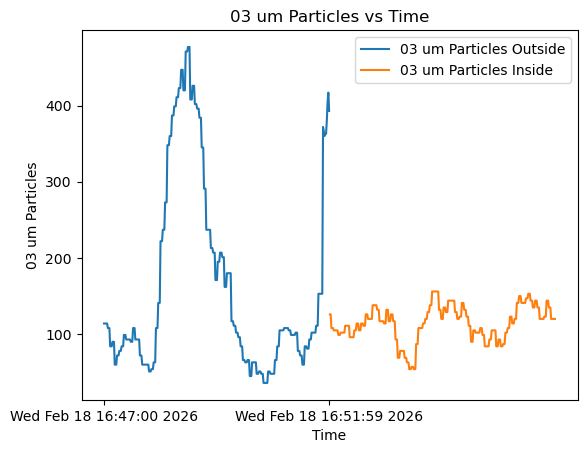

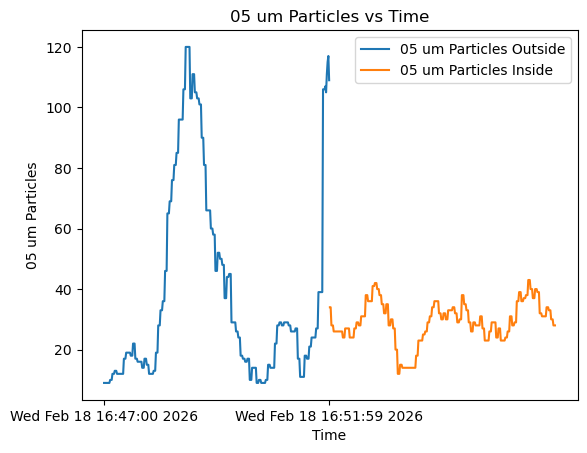

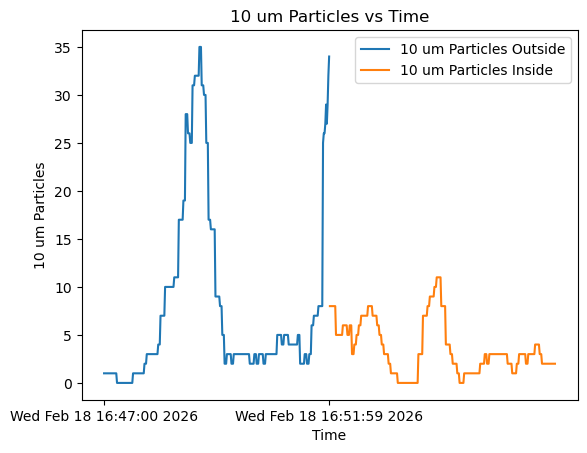

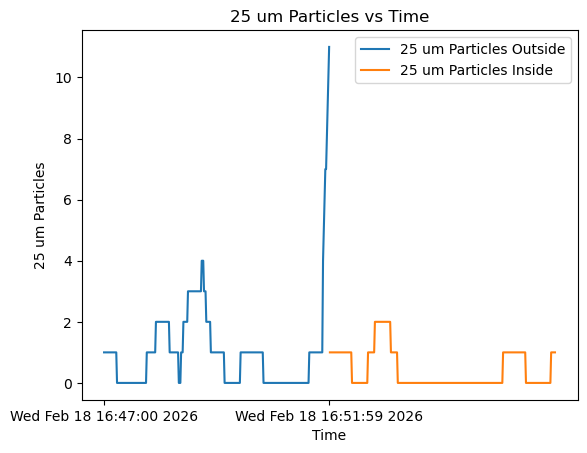

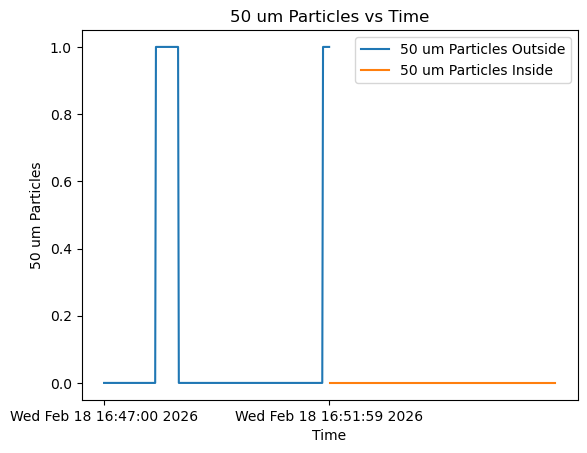

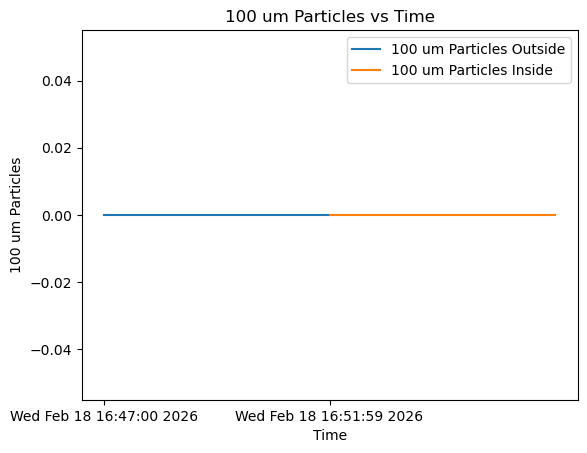

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = []
dataOutside = pd.read_csv("Lab5Out.csv")
data.append(dataOutside)
dataInside = pd.read_csv("Lab5In.csv")
data.append(dataInside)

labelList = ["Time", "Temperature", "Gas", "Humidity", "Pressure", "Altitude", "Standard 10", "Standard 25", "Standard 100", "Environmental 10", "Environmental 25", "Environmental 100", "03 um Particles", "05 um Particles", "10 um Particles", "25 um Particles", "50 um Particles", "100 um Particles"]

for i in range(2):
    data[i] = data[i].iloc[145 : 441, :]

for i in range(1, data[0].shape[1]): #iterate between columns
    plt.plot(data[0].iloc[:, 0], data[0].iloc[:, i], label = labelList[i] + " Outside")
    plt.plot(data[1].iloc[:, 0], data[1].iloc[:, i], label = labelList[i] + " Inside")
    plt.xlabel("Time")
    plt.xticks([0, 295])
    plt.ylabel(labelList[i])
    plt.title(labelList[i] + " vs Time")
    plt.legend()
    plt.show()

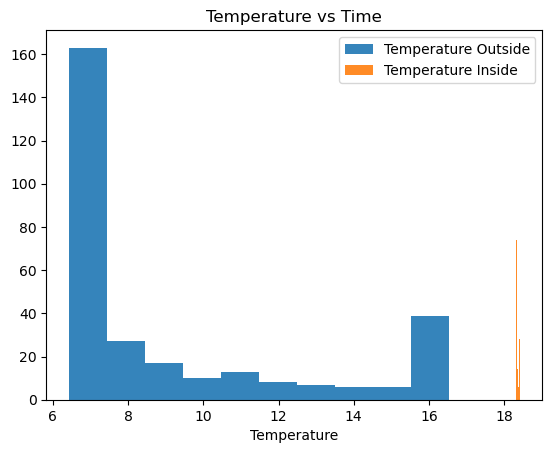

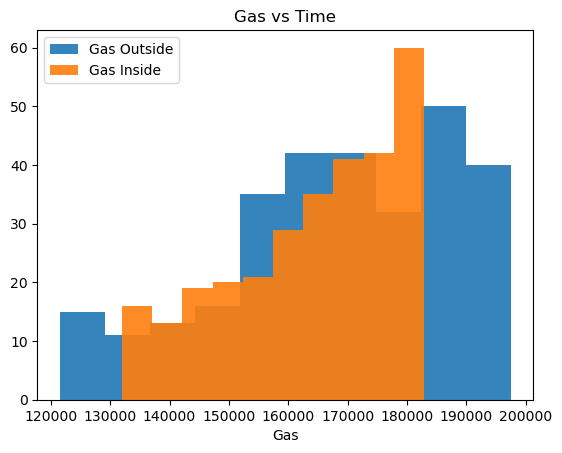

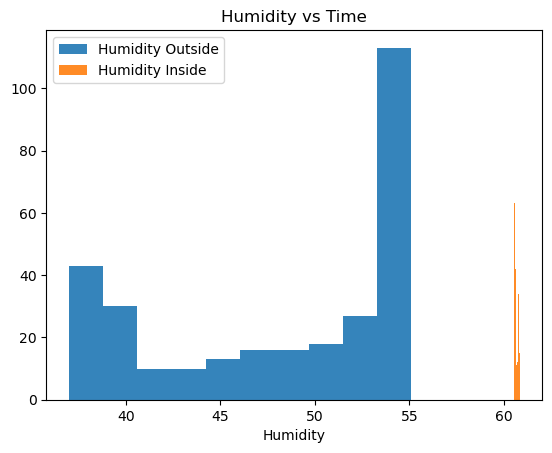

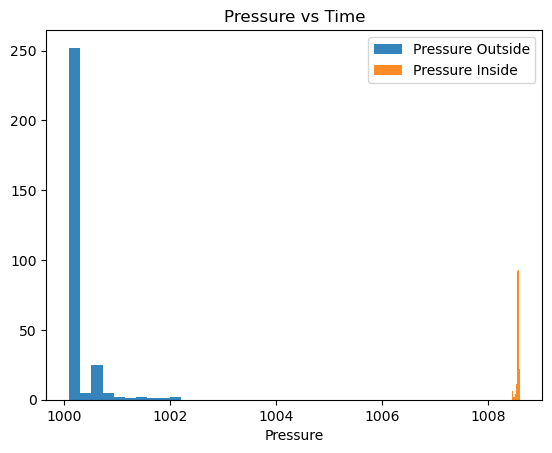

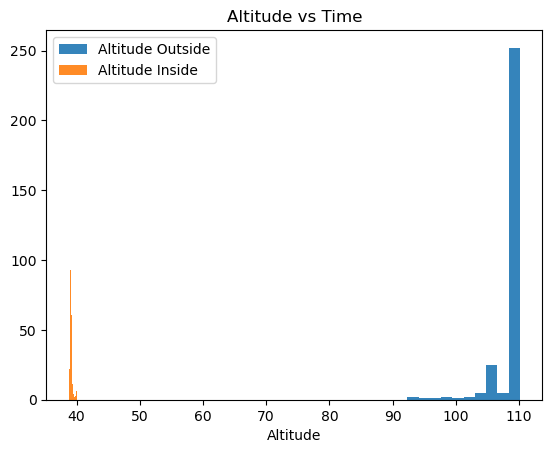

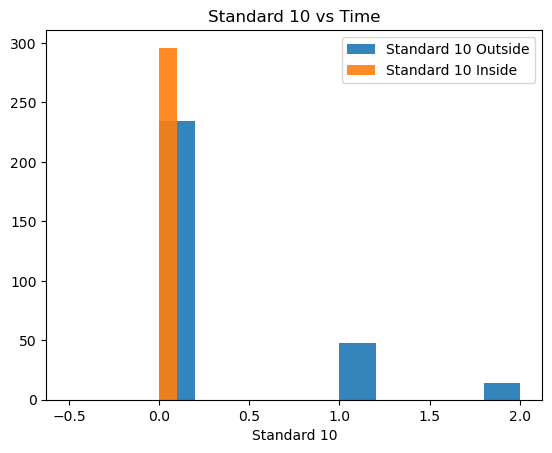

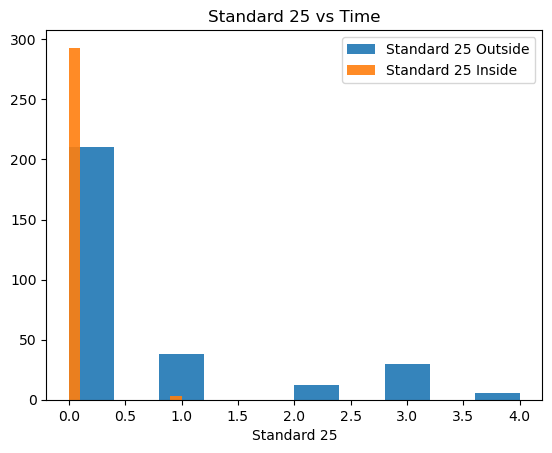

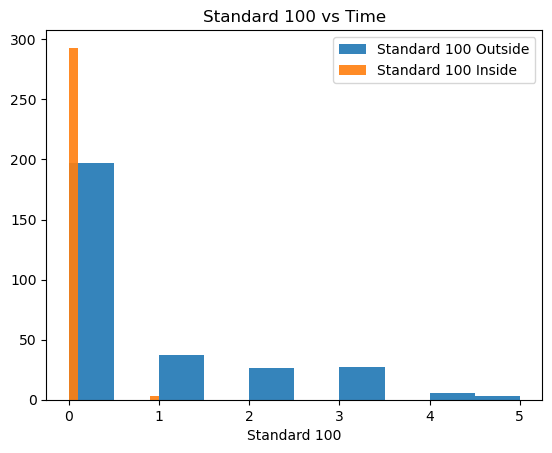

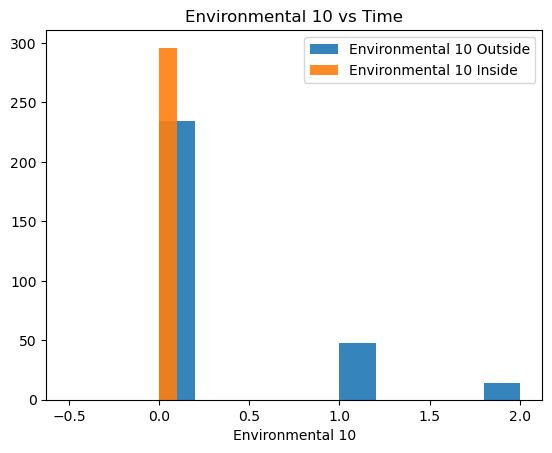

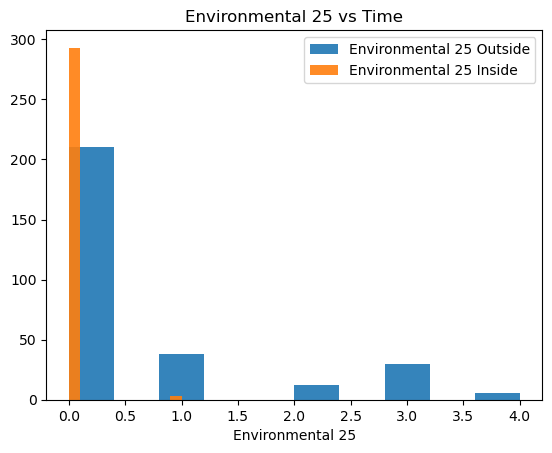

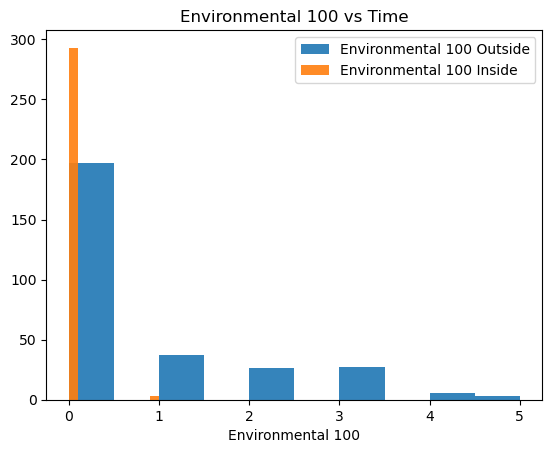

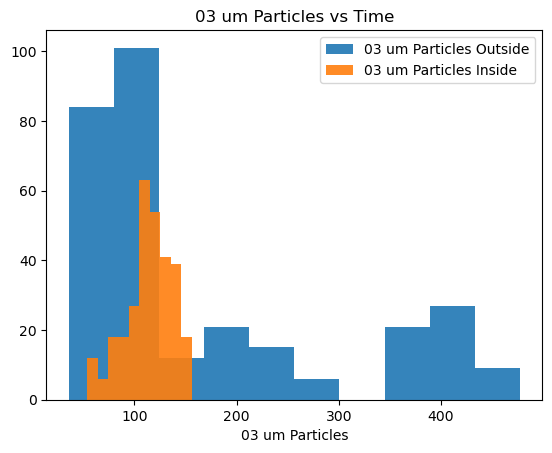

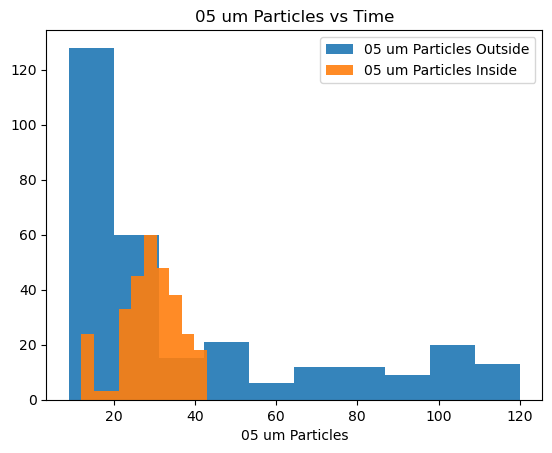

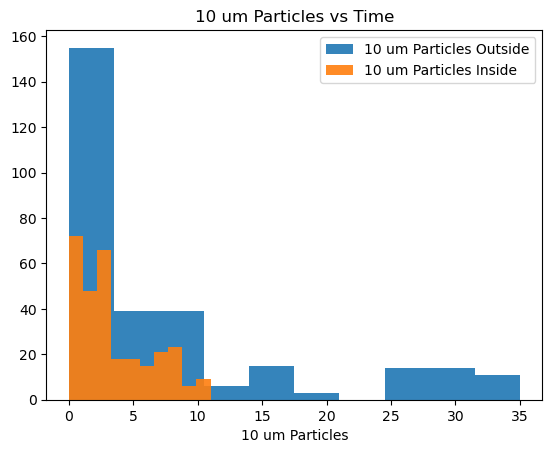

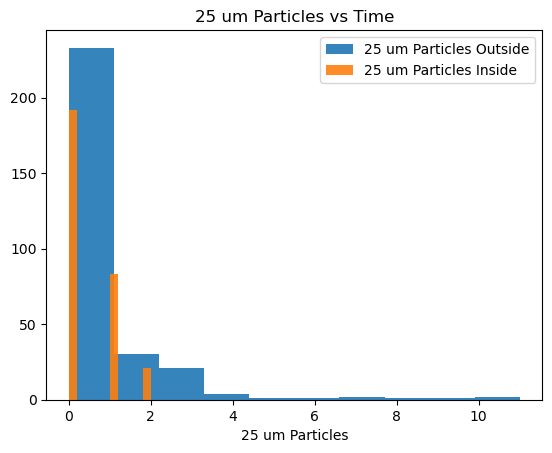

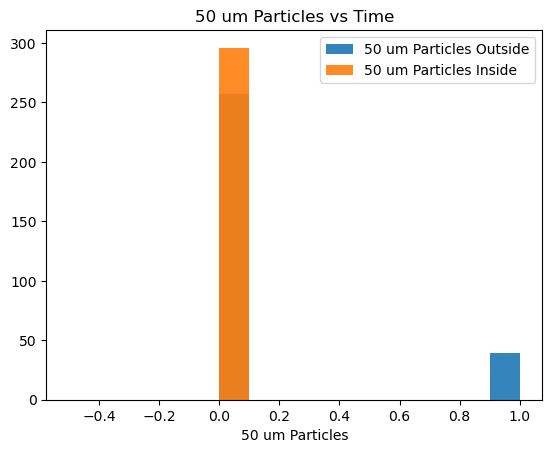

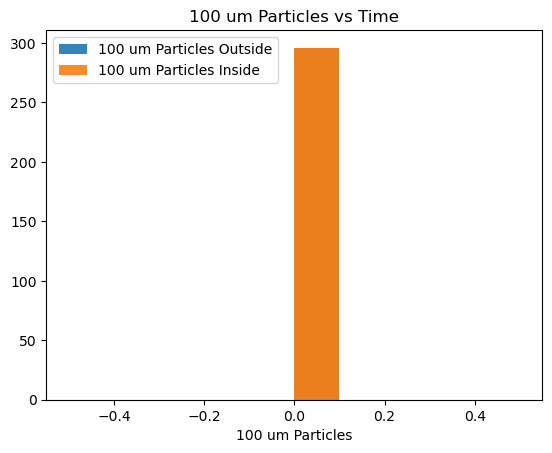

In [4]:
for i in range(1, data[0].shape[1]): #iterate between columns
    plt.hist(data[0].iloc[:, i], alpha = 0.9, label = labelList[i] + " Outside") #figure out bins
    plt.hist(data[1].iloc[:, i], alpha = 0.9, label = labelList[i] + " Inside")
    plt.xlabel(labelList[i])
    plt.title(labelList[i] + " vs Time")
    plt.legend()
    plt.show()

In [12]:
def takeMean(dataSet):
    total = 0
    num = len(dataSet)
    
    for i in dataSet:
        total += float(i)
    return total / num

def takeStd(dataSet, mean):
    sumOf = 0
    num = len(dataSet)
    
    for i in dataSet:
        sumOf += (i - mean) ** 2
    return np.sqrt(sumOf / (num - 1))

for j in range(1, data[0].shape[1]):
    meanTempOut = takeMean(data[0].iloc[:, j])
    stdTempOut = takeStd(data[0].iloc[:, j], takeMean(data[0].iloc[:, j]))
    uncTempOut =  stdTempOut / np.sqrt(len(data[0].iloc[:, j]))
    meanTempIn = takeMean(data[1].iloc[:, j])
    stdTempIn = takeStd(data[1].iloc[:, j], takeMean(data[1].iloc[:, j]))
    uncTempIn = stdTempIn / np.sqrt(len(data[1].iloc[:, j]))
    stdErrTemp = np.sqrt((stdTempOut**2 / len(data[0].iloc[:, j])) + (stdTempIn**2 / len(data[1].iloc[:, j])))
    print(labelList[j] + " statistically different: " + str(abs(meanTempOut - meanTempIn) > (3 * stdErrTemp)))

Temperature statistically different: True
Gas statistically different: True
Humidity statistically different: True
Pressure statistically different: True
Altitude statistically different: True
Standard 10 statistically different: True
Standard 25 statistically different: True
Standard 100 statistically different: True
Environmental 10 statistically different: True
Environmental 25 statistically different: True
Environmental 100 statistically different: True
03 um Particles statistically different: True
05 um Particles statistically different: True
10 um Particles statistically different: True
25 um Particles statistically different: True
50 um Particles statistically different: True
100 um Particles statistically different: False
